Genetic Fuzzy Tip Recommender

> Add blockquote



In this notebook, I:

1. Rebuild the Lab 4 fuzzy tree (Food FIS + Service FIS + Tipper FIS) as a **baseline**.
2. Load the Lab 5 tipping dataset (**train** and **test** CSVs).
3. Clean the dataset by clipping input attributes to \[0, 1\], and use tip in \[0, 30\].
4. Use **EasyGA** to optimize all triangular membership functions in a **genetic fuzzy tree**.
5. Rebuild an optimized fuzzy tree from the GA's best chromosome.
6. Compare baseline vs. optimized systems on the **test** dataset.


## 0. Install and import libraries

### Resource References

I followed the Lab 5 resource guidance:
- Kruse et al., *Computational Intelligence* (Ch. 11–13.1, 21.2) for fuzzy and GA theory.
- ECE 449 slides from Dr. Musilek on Evolutionary Computation/Optimization and Genetic Algorithms.
- `scikit-fuzzy` documentation and examples for explicit membership-function design.
- EasyGA GitHub/docs for GA API usage and configuration tips.



In [ ]:
# I ensure required libraries are available using import checks
!pip install scikit-fuzzy
!pip install EasyGA --no-deps
import importlib
import subprocess
import sys

import EasyGA
import re
import io

import numpy as np
import pandas as pd
import random

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import EasyGA  # I use EasyGA for the genetic algorithm implementation


## 1. Load and clean the Lab 5 datasets

I load the tipping dataset which is **already divided into training and test sets** as two CSVs:

- One for **training**
- One for **out-of-sample testing**

**Data cleaning (per assignment specification):**
- Input attributes may fall outside \[0, 1\] due to noise.
- I **clip them** so values < 0 become 0, and values > 1 become 1.
- Tip is in **\[0, 30\]** for this lab.


In [ ]:
TRAIN_CSV_PATH = "tipper_train.csv"
TEST_CSV_PATH  = "tipper_test.csv"

train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df  = pd.read_csv(TEST_CSV_PATH)

# I identify the input columns that need clipping (matching actual CSV column names)
cols_to_clean = [
    "food temperature",
    "food flavor",
    "portion size",
    "attentiveness",
    "friendliness",
    "speed of service",
]
target_col = "tip"

# I clip input attributes to [0, 1] as required by the assignment
for col in cols_to_clean:
    train_df[col] = train_df[col].clip(0.0, 1.0)
    test_df[col]  = test_df[col].clip(0.0, 1.0)

print("Train set shape:", train_df.shape)
print("Test set shape :", test_df.shape)

train_df.head()

Train set shape: (208, 7)
Test set shape : (52, 7)


,food temperature,food flavor,portion size,attentiveness,friendliness,speed of service,tip
0,0.004099,0.998592,0.501296,0.032967,0.541829,0.569224,12.000000
1,0.282108,0.459470,0.000000,0.672237,1.000000,0.780601,19.987339
2,0.776767,0.752571,0.607890,0.064566,0.091971,0.520506,15.000000
3,0.277898,0.073231,0.524066,0.658515,0.000000,0.467473,15.000810
4,0.014611,0.250494,0.807616,0.516680,0.773835,1.000000,15.000000


## 2. Baseline fuzzy tree (Lab 4 structure)

I re-create the **Lab 4 fuzzy tree** as a baseline for comparison:

1. **Food Quality FIS**
   - Inputs: temperature, flavor, portion_size (0–10)
   - Output: food_quality (0–10)

2. **Service Quality FIS**
   - Inputs: attentiveness, friendliness, speed (0–10)
   - Output: service_quality (0–10)

3. **Tipper FIS**
   - Inputs: food_quality_for_tip, service_quality_for_tip (0–10)
   - Output: tip (0–30) for this lab

I keep the baseline membership functions using `automf(3)` just like Lab 4
(this is the **unoptimized** system). The GA-optimized system uses
explicit `fuzz.trimf` parameters.


In [ ]:
# I define universes of discourse
x_quality = np.linspace(0, 10, 101)
x_tip     = np.linspace(0, 30, 121)

# ---------- Food Quality FIS (baseline) ----------
b_temperature   = ctrl.Antecedent(x_quality, 'temperature')
b_flavor        = ctrl.Antecedent(x_quality, 'flavor')
b_portion_size  = ctrl.Antecedent(x_quality, 'portion_size')
b_food_quality  = ctrl.Consequent(x_quality, 'food_quality')

b_temperature.automf(3)   # I use automf to create poor / average / good membership functions
b_flavor.automf(3)
b_portion_size.automf(3)
b_food_quality.automf(3)

rule1_food = ctrl.Rule(
    b_temperature['poor'] | b_flavor['poor'] | b_portion_size['poor'],
    b_food_quality['poor']
)
rule2_food = ctrl.Rule(
    b_temperature['average'] & b_flavor['average'] & b_portion_size['average'],
    b_food_quality['average']
)
rule3_food = ctrl.Rule(
    b_temperature['good'] & b_flavor['good'] & b_portion_size['good'],
    b_food_quality['good']
)

b_food_ctrl = ctrl.ControlSystem([rule1_food, rule2_food, rule3_food])
b_food_sim  = ctrl.ControlSystemSimulation(b_food_ctrl)

# ---------- Service Quality FIS (baseline) ----------
b_attentiveness   = ctrl.Antecedent(x_quality, 'attentiveness')
b_friendliness    = ctrl.Antecedent(x_quality, 'friendliness')
b_speed           = ctrl.Antecedent(x_quality, 'speed')
b_service_quality = ctrl.Consequent(x_quality, 'service_quality')

b_attentiveness.automf(3)
b_friendliness.automf(3)
b_speed.automf(3)
b_service_quality.automf(3)

rule1_service = ctrl.Rule(
    b_attentiveness['poor'] | b_friendliness['poor'] | b_speed['poor'],
    b_service_quality['poor']
)
rule2_service = ctrl.Rule(
    b_attentiveness['average'] & b_friendliness['average'] & b_speed['average'],
    b_service_quality['average']
)
rule3_service = ctrl.Rule(
    b_attentiveness['good'] & b_friendliness['good'] & b_speed['good'],
    b_service_quality['good']
)

b_service_ctrl = ctrl.ControlSystem([rule1_service, rule2_service, rule3_service])
b_service_sim  = ctrl.ControlSystemSimulation(b_service_ctrl)

# ---------- Tipper FIS (baseline) ----------
b_food_quality_for_tip    = ctrl.Antecedent(x_quality, 'food_quality_for_tip')
b_service_quality_for_tip = ctrl.Antecedent(x_quality, 'service_quality_for_tip')
b_tip                     = ctrl.Consequent(x_tip, 'tip')

b_food_quality_for_tip.automf(3)
b_service_quality_for_tip.automf(3)
b_tip.automf(3)

rule1_tip = ctrl.Rule(
    b_food_quality_for_tip['poor'] | b_service_quality_for_tip['poor'],
    b_tip['poor']
)
rule2_tip = ctrl.Rule(
    b_food_quality_for_tip['average'] & b_service_quality_for_tip['average'],
    b_tip['average']
)
rule3_tip = ctrl.Rule(
    b_food_quality_for_tip['good'] & b_service_quality_for_tip['good'],
    b_tip['good']
)

b_tip_ctrl = ctrl.ControlSystem([rule1_tip, rule2_tip, rule3_tip])
b_tip_sim  = ctrl.ControlSystemSimulation(b_tip_ctrl)

### 2.1 Baseline prediction helper

Dataset inputs are in **[0,1]**, so I re-scale them to **[0,10]** for the fuzzy variables.


In [ ]:
def baseline_predict_tip(row):
    """
    I predict tip using the baseline fuzzy system.
    row: pandas Series with [0,1]-scaled input features.
    Returns: predicted tip in [0, 30].
    """
    # I re-scale inputs from [0,1] -> [0,10]
    t  = float(row["food temperature"])   * 10.0
    f  = float(row["food flavor"])        * 10.0
    ps = float(row["portion size"])       * 10.0
    a  = float(row["attentiveness"])      * 10.0
    fr = float(row["friendliness"])       * 10.0
    s  = float(row["speed of service"])    * 10.0

    # Food stage
    b_food_sim.input['temperature']   = t
    b_food_sim.input['flavor']        = f
    b_food_sim.input['portion_size']  = ps
    b_food_sim.compute()
    food_q = b_food_sim.output['food_quality']

    # Service stage
    b_service_sim.input['attentiveness'] = a
    b_service_sim.input['friendliness']  = fr
    b_service_sim.input['speed']         = s
    b_service_sim.compute()
    serv_q = b_service_sim.output['service_quality']

    # Tipper stage
    b_tip_sim.input['food_quality_for_tip']    = food_q
    b_tip_sim.input['service_quality_for_tip'] = serv_q
    b_tip_sim.compute()
    tip_pred = b_tip_sim.output['tip']

    return tip_pred

### 2.2 Baseline MAE on train and test

In [ ]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

y_train_true = train_df[target_col].values
y_test_true  = test_df[target_col].values

baseline_train_pred = [baseline_predict_tip(row) for _, row in train_df.iterrows()]
baseline_test_pred  = [baseline_predict_tip(row) for _, row in test_df.iterrows()]

baseline_train_mae = mean_absolute_error(y_train_true, baseline_train_pred)
baseline_test_mae  = mean_absolute_error(y_test_true,  baseline_test_pred)

print(f"Baseline MAE (train): {baseline_train_mae:.4f}")
print(f"Baseline MAE (test) : {baseline_test_mae:.4f}")

Baseline MAE (train): 4.4696
Baseline MAE (test) : 3.8342


## 3. Genetic encoding: membership functions → genes

For the **genetic fuzzy tree**, I encode membership function parameters as genes:

- **Variable-length encoding**: I use different numbers of membership functions for different variables
  - Variables with 3 MFs (poor, average, good): 3 genes each
  - Variables with 5 MFs (very_low, low, medium, high, very_high): 5 genes each
- **Gene order**: temperature (3), flavor (5), portion_size (3), attentiveness (3), friendliness (3), speed (5), food_quality (3), service_quality (3), food_quality_for_tip (3), service_quality_for_tip (3), tip (3)
- **Total chromosome length**: 37 genes
- Genes are in [0,1] and I sort them per variable before creating membership functions


In [ ]:
# I calculate chromosome length: 3 + 5 + 3 + 3 + 3 + 5 + 3 + 3 + 3 + 3 + 3 = 37
# Gene order: temperature, flavor, portion_size, attentiveness, friendliness, speed,
#             food_quality, service_quality, food_quality_for_tip, service_quality_for_tip, tip
chromosome_length = 3 + 5 + 3 + 3 + 3 + 5 + 3 + 3 + 3 + 3 + 3
print("Chromosome length:", chromosome_length)


def setup_mf3(var, g1, g2, g3):
    """
    I create 3 membership functions (poor, average, good) from sorted genes.
    I scale genes from [0,1] into the universe range.
    """
    umin = var.universe.min()
    umax = var.universe.max()
    span = umax - umin

    c1 = umin + g1 * span
    c2 = umin + g2 * span
    c3 = umin + g3 * span

    var['poor']    = fuzz.trimf(var.universe, [umin, umin, c2])
    var['average'] = fuzz.trimf(var.universe, [c1,  c2,  c3])
    var['good']    = fuzz.trimf(var.universe, [c2,  umax, umax])


def setup_mf5(var, g1, g2, g3, g4, g5):
    """
    I create 5 membership functions (very_low, low, medium, high, very_high) from sorted genes.
    I scale genes from [0,1] into universe range.
    """
    umin = var.universe.min()
    umax = var.universe.max()
    span = umax - umin

    c1 = umin + g1 * span
    c2 = umin + g2 * span
    c3 = umin + g3 * span
    c4 = umin + g4 * span
    c5 = umin + g5 * span

    var['very_low']  = fuzz.trimf(var.universe, [umin, c1, c2])
    var['low']       = fuzz.trimf(var.universe, [c1,  c2, c3])
    var['medium']    = fuzz.trimf(var.universe, [c2,  c3, c4])
    var['high']      = fuzz.trimf(var.universe, [c3,  c4, c5])
    var['very_high'] = fuzz.trimf(var.universe, [c4,  c5, umax])


def chromosome_to_list(chromosome):
    """
    I convert an EasyGA chromosome (or similar) to a list of floats.
    """
    if hasattr(chromosome, "genes"):
        return [g.value for g in chromosome.genes]
    try:
        return [g.value for g in chromosome]
    except Exception:
        return list(chromosome)

Chromosome length: 37


### 3.1 Setup fuzzy system from chromosome

My `setup_fuzzy_system` function takes a chromosome (list of 37 genes) and:
1. Extracts genes in the fixed order for each variable
2. Sorts genes per variable to ensure ordering
3. Calls `setup_mf3` or `setup_mf5` to create membership functions
4. Defines the same rule structure as Lab 4 (but adapted for 5-MF variables where applicable)


In [ ]:
def setup_fuzzy_system(chromosome):
    """
    I build fuzzy inference systems from a chromosome (list of 37 genes).
    Returns: (food_ctrl, service_ctrl, tip_ctrl) - ControlSystem objects
    """
    # I convert chromosome to list of floats if needed
    genes = chromosome_to_list(chromosome)

    # I set up the Antecedents (input variables)
    # Food Quality
    temperature = ctrl.Antecedent(np.linspace(0, 10, 11), 'temperature')
    flavor = ctrl.Antecedent(np.linspace(0, 10, 11), 'flavor')
    portion_size = ctrl.Antecedent(np.linspace(0, 10, 11), 'portion_size')
    # Service quality
    attentiveness = ctrl.Antecedent(np.linspace(0, 10, 11), 'attentiveness')
    friendliness = ctrl.Antecedent(np.linspace(0, 10, 11), 'friendliness')
    speed = ctrl.Antecedent(np.linspace(0, 10, 11), 'speed')
    # 1st-stage FIS outputs (defuzzified)
    food_quality = ctrl.Consequent(np.linspace(0, 10, 11), 'food_quality', defuzzify_method='centroid')
    service_quality = ctrl.Consequent(np.linspace(0, 10, 11), 'service_quality', defuzzify_method='centroid')
    # 2nd-stage inputs
    food_quality_for_tip = ctrl.Antecedent(np.linspace(0, 10, 11), 'food_quality_for_tip')
    service_quality_for_tip = ctrl.Antecedent(np.linspace(0, 10, 11), 'service_quality_for_tip')
    # 2nd-stage FIS output
    tip = ctrl.Consequent(np.linspace(0, 30, 31), 'tip', defuzzify_method='centroid')

    # I assign genes explicitly in fixed order
    idx = 0
    # temperature (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_temp = sorted([g1, g2, g3])
    setup_mf3(temperature, genes_temp[0], genes_temp[1], genes_temp[2])

    # flavor (5 genes)
    g1, g2, g3, g4, g5 = genes[idx], genes[idx+1], genes[idx+2], genes[idx+3], genes[idx+4]
    idx += 5
    genes_flavor = sorted([g1, g2, g3, g4, g5])
    setup_mf5(flavor, genes_flavor[0], genes_flavor[1], genes_flavor[2], genes_flavor[3], genes_flavor[4])

    # portion_size (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_portion = sorted([g1, g2, g3])
    setup_mf3(portion_size, genes_portion[0], genes_portion[1], genes_portion[2])

    # attentiveness (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_att = sorted([g1, g2, g3])
    setup_mf3(attentiveness, genes_att[0], genes_att[1], genes_att[2])

    # friendliness (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_friend = sorted([g1, g2, g3])
    setup_mf3(friendliness, genes_friend[0], genes_friend[1], genes_friend[2])

    # speed (5 genes)
    g1, g2, g3, g4, g5 = genes[idx], genes[idx+1], genes[idx+2], genes[idx+3], genes[idx+4]
    idx += 5
    genes_speed = sorted([g1, g2, g3, g4, g5])
    setup_mf5(speed, genes_speed[0], genes_speed[1], genes_speed[2], genes_speed[3], genes_speed[4])

    # food_quality (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_fq = sorted([g1, g2, g3])
    setup_mf3(food_quality, genes_fq[0], genes_fq[1], genes_fq[2])

    # service_quality (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_sq = sorted([g1, g2, g3])
    setup_mf3(service_quality, genes_sq[0], genes_sq[1], genes_sq[2])

    # food_quality_for_tip (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_fqt = sorted([g1, g2, g3])
    setup_mf3(food_quality_for_tip, genes_fqt[0], genes_fqt[1], genes_fqt[2])

    # service_quality_for_tip (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_sqt = sorted([g1, g2, g3])
    setup_mf3(service_quality_for_tip, genes_sqt[0], genes_sqt[1], genes_sqt[2])

    # tip (3 genes)
    g1, g2, g3 = genes[idx], genes[idx+1], genes[idx+2]
    idx += 3
    genes_tip = sorted([g1, g2, g3])
    setup_mf3(tip, genes_tip[0], genes_tip[1], genes_tip[2])

    # I define fuzzy rules with the same structure as Lab 4, adapted for 5-MF variables

    ## Fuzzy rules for Food Quality
    rule1_food = ctrl.Rule(temperature['poor'] | portion_size['poor'] | flavor['very_low'], food_quality['poor'])
    rule2_food = ctrl.Rule(temperature['average'] | portion_size['average'] | flavor['medium'], food_quality['average'])
    rule3_food = ctrl.Rule(flavor['very_high'] | (temperature['good'] & portion_size['good']), food_quality['good'])
    rule4_food = ctrl.Rule(flavor['very_high'] & (temperature['average'] | portion_size['average']), food_quality['good'])
    rule5_food = ctrl.Rule(flavor['low'] & (temperature['good'] & portion_size['good']), food_quality['average'])
    rule6_food = ctrl.Rule((flavor['high'] & (temperature['good'] | portion_size['good'])), food_quality['good'])
    rule7_food = ctrl.Rule((temperature['poor'] & portion_size['average']) | (portion_size['poor'] & temperature['average']), food_quality['poor'])
    rule8_food = ctrl.Rule((flavor['low'] & (temperature['average'] | portion_size['average'])), food_quality['average'])
    rule9_food = ctrl.Rule(temperature['good'] & portion_size['good'] & (flavor['high'] | flavor['very_high']), food_quality['good'])

    ## Fuzzy rules for Service Quality
    rule1_serv = ctrl.Rule(attentiveness['poor'] | friendliness['poor'] | speed['very_low'], service_quality['poor'])
    rule2_serv = ctrl.Rule(attentiveness['average'] | friendliness['average'] | speed['medium'], service_quality['average'])
    rule3_serv = ctrl.Rule(speed['very_high'] | (attentiveness['good'] & friendliness['good']), service_quality['good'])
    rule4_serv = ctrl.Rule(speed['very_low'] & (attentiveness['good'] | friendliness['good']), service_quality['poor'])
    rule5_serv = ctrl.Rule(speed['very_high'] & (attentiveness['average'] | friendliness['average']), service_quality['good'])
    rule7_serv = ctrl.Rule((speed['low'] & (attentiveness['average'] | friendliness['average'])), service_quality['poor'])
    rule8_serv = ctrl.Rule((speed['medium'] & (attentiveness['good'] | friendliness['good'])), service_quality['good'])
    rule9_serv = ctrl.Rule(attentiveness['good'] & friendliness['good'] & (speed['high'] | speed['very_high']), service_quality['good'])

    ## Fuzzy rules for Tipper
    rule1_tip = ctrl.Rule(food_quality_for_tip['poor'] | service_quality_for_tip['poor'], tip['poor'])
    rule2_tip = ctrl.Rule(food_quality_for_tip['average'] & service_quality_for_tip['average'], tip['average'])
    rule3_tip = ctrl.Rule(food_quality_for_tip['good'] | service_quality_for_tip['good'], tip['good'])
    rule4_tip = ctrl.Rule((food_quality_for_tip['good'] & service_quality_for_tip['average']) | (food_quality_for_tip['average'] & service_quality_for_tip['good']), tip['good'])
    rule5_tip = ctrl.Rule((food_quality_for_tip['poor'] & service_quality_for_tip['average']) | (food_quality_for_tip['average'] & service_quality_for_tip['poor']), tip['poor'])
    rule6_tip = ctrl.Rule((food_quality_for_tip['average'] & service_quality_for_tip['average']), tip['average'])
    rule7_tip = ctrl.Rule(food_quality_for_tip['good'] & service_quality_for_tip['good'], tip['good'])

    # I define the control systems
    food_ctrl = ctrl.ControlSystem([rule1_food, rule2_food, rule3_food, rule4_food, rule5_food, rule6_food, rule7_food, rule8_food, rule9_food])
    service_ctrl = ctrl.ControlSystem([rule1_serv, rule2_serv, rule3_serv, rule4_serv, rule5_serv, rule7_serv, rule8_serv, rule9_serv])
    tip_ctrl = ctrl.ControlSystem([rule1_tip, rule2_tip, rule3_tip, rule4_tip, rule5_tip, rule6_tip, rule7_tip])

    return food_ctrl, service_ctrl, tip_ctrl

## 4. Inference function for GA-based system

My `execute_fuzzy_inference` function takes control systems and input values,
runs the three-stage fuzzy inference, and returns the predicted tip.


In [ ]:
def execute_fuzzy_inference(food_ctrl, service_ctrl, tip_ctrl, inputs):
    """
    I execute three-stage fuzzy inference.
    inputs: dict with keys "temperature", "flavor", "portion_size",
            "attentiveness", "friendliness", "speed" (values in [0,10])
    Returns: predicted tip value
    """
    # I set up simulation objects
    food_sim = ctrl.ControlSystemSimulation(food_ctrl)
    serv_sim = ctrl.ControlSystemSimulation(service_ctrl)
    tip_sim = ctrl.ControlSystemSimulation(tip_ctrl)

    # Stage 1: food quality and service quality
    food_sim.input["temperature"] = inputs["temperature"]
    food_sim.input["flavor"] = inputs["flavor"]
    food_sim.input["portion_size"] = inputs["portion_size"]
    serv_sim.input["attentiveness"] = inputs["attentiveness"]
    serv_sim.input["friendliness"] = inputs["friendliness"]
    serv_sim.input["speed"] = inputs["speed"]
    food_sim.compute()
    serv_sim.compute()
    food_q = food_sim.output["food_quality"]
    serv_q = serv_sim.output["service_quality"]

    # Stage 2: tip
    tip_sim = ctrl.ControlSystemSimulation(tip_ctrl)
    tip_sim.input["food_quality_for_tip"] = food_q
    tip_sim.input["service_quality_for_tip"] = serv_q
    tip_sim.compute()

    # Return simulated tip
    return tip_sim.output["tip"]


def evaluate_chromosome_on_dataset(chromosome, df):
    """
    I evaluate a chromosome on a dataset (train or test).
    Returns: mean absolute error
    """
    food_ctrl, service_ctrl, tip_ctrl = setup_fuzzy_system(chromosome)
    total_error = 0.0
    for _, row in df.iterrows():
        inputs = {
            "temperature":   row["food temperature"] * 10.0,
            "flavor":        row["food flavor"] * 10.0,
            "portion_size":  row["portion size"] * 10.0,
            "attentiveness": row["attentiveness"] * 10.0,
            "friendliness":  row["friendliness"] * 10.0,
            "speed":         row["speed of service"] * 10.0,
        }
        actual_tip = row["tip"]
        predicted_tip = execute_fuzzy_inference(food_ctrl, service_ctrl, tip_ctrl, inputs)
        total_error += abs(actual_tip - predicted_tip)
    return total_error / len(df)

### 4.2 Baseline chromosome

I create an explicit baseline chromosome with reasonable default values.
This allows me to evaluate the baseline using the same fuzzy system structure as the GA-optimized version.


In [ ]:
# I define a baseline chromosome with explicit default values
# Gene order: temperature (3), flavor (5), portion_size (3), attentiveness (3),
#             friendliness (3), speed (5), food_quality (3), service_quality (3),
#             food_quality_for_tip (3), service_quality_for_tip (3), tip (3)
baseline_chromosome = [
    # temperature (3)
    0.2, 0.5, 0.8,
    # flavor (5)
    0.0, 0.25, 0.5, 0.75, 1.0,
    # portion_size (3)
    0.2, 0.5, 0.8,
    # attentiveness (3)
    0.2, 0.5, 0.8,
    # friendliness (3)
    0.2, 0.5, 0.8,
    # speed (5)
    0.0, 0.25, 0.5, 0.75, 1.0,
    # food_quality (3)
    0.2, 0.5, 0.8,
    # service_quality (3)
    0.2, 0.5, 0.8,
    # food_quality_for_tip (3)
    0.2, 0.5, 0.8,
    # service_quality_for_tip (3)
    0.2, 0.5, 0.8,
    # tip (3)
    0.2, 0.5, 0.8
]

baseline_train_mae = evaluate_chromosome_on_dataset(baseline_chromosome, train_df)
baseline_test_mae  = evaluate_chromosome_on_dataset(baseline_chromosome, test_df)

print(f"Baseline train MAE: {baseline_train_mae:.3f}")
print(f"Baseline test  MAE:  {baseline_test_mae:.3f}")


Baseline train MAE: 3.943
Baseline test  MAE:  4.057


### 4.1 Inference helper for GA-based system

Note: This section contains a legacy helper function. The main inference is handled by `execute_fuzzy_inference`.

In [ ]:
def ga_system_predict_tip(row, food_sim, service_sim, tip_sim):
    """
    I use the GA-optimized fuzzy system to predict tip on a single row.
    row: pandas Series with inputs in [0,1].
    """
    t  = float(row["food temperature"])   * 10.0
    f  = float(row["food flavor"])        * 10.0
    ps = float(row["portion size"])       * 10.0
    a  = float(row["attentiveness"])      * 10.0
    fr = float(row["friendliness"])       * 10.0
    s  = float(row["speed of service"])    * 10.0

    # I compute food quality
    food_sim.input['temperature']   = t
    food_sim.input['flavor']        = f
    food_sim.input['portion_size']  = ps
    food_sim.compute()
    food_q = food_sim.output['food_quality']

    # I compute service quality
    service_sim.input['attentiveness'] = a
    service_sim.input['friendliness']  = fr
    service_sim.input['speed']         = s
    service_sim.compute()
    serv_q = service_sim.output['service_quality']

    # I compute tip
    tip_sim.input['food_quality_for_tip']    = food_q
    tip_sim.input['service_quality_for_tip'] = serv_q
    tip_sim.compute()
    tip_pred = tip_sim.output['tip']

    return tip_pred

## 5. GA fitness function and configuration

The fitness function:

- Decodes the chromosome into MF parameters.
- Builds a fuzzy system from those parameters.
- Runs the system on **all training rows**.
- Computes **mean absolute error (MAE)** between predicted and actual tips.
- Returns MAE, and we configure the GA with `target_fitness_type = 'min'` as shown in the lab presentation.

In [ ]:
def fitness(chromosome):
    """
    I define the EasyGA fitness function.
    Returns total absolute error (to be minimized).
    """
    try:
        food_ctrl, service_ctrl, tip_ctrl = setup_fuzzy_system(chromosome)
    except Exception:
        # If the chromosome cannot be converted or the fuzzy system
        # cannot be built, I penalize heavily.
        return 1e9

    total_error = 0.0
    for _, row in train_df.iterrows():
        try:
            inputs = {
                "temperature":   row["food temperature"] * 10.0,
                "flavor":        row["food flavor"] * 10.0,
                "portion_size":  row["portion size"] * 10.0,
                "attentiveness": row["attentiveness"] * 10.0,
                "friendliness":  row["friendliness"] * 10.0,
                "speed":         row["speed of service"] * 10.0,
            }
            actual_tip = row["tip"]
            predicted_tip = execute_fuzzy_inference(
                food_ctrl, service_ctrl, tip_ctrl, inputs
            )
            total_error += abs(actual_tip - predicted_tip)
        except Exception:
            # If inference fails for any row, I penalize heavily.
            return 1e9

    return total_error  # GA minimizes this


### 5.1 GA setup (EasyGA)

Following the presentation, I:

- Use `GA()` from EasyGA.
- Set `chromosome_length`, `population_size`, `generation_goal`.
- Provide `fitness_function_impl`.
- Use `gene_impl` that generates random floats in [0,1].
- Set `target_fitness_type = 'min'` so the GA minimizes MAE.
- Call `ga.evolve()` to evolve the population.


In [ ]:
GA_SETTINGS = {
    "population_size": 20,
    "generation_goal": 30,
    "max_attempts": 1,
    "base_seed": 12345,
}


def configure_ga(seed=None):
    """I create a GA instance that follows the Lab 5 slide template."""
    ga = EasyGA.GA()
    ga.chromosome_length = chromosome_length
    ga.population_size = GA_SETTINGS["population_size"]
    ga.generation_goal = GA_SETTINGS["generation_goal"]
    ga.fitness_function_impl = fitness
    ga.target_fitness_type = 'min'
    ga.gene_impl = lambda: random.random()
    if seed is not None:
        ga.seed = seed
    return ga

### 5.2 Run GA evolution

In [ ]:
def run_ga_attempt(seed):
    """I run one GA attempt with a specific seed and return metrics."""
    print(f"Running GA attempt with seed={seed} ...")
    random.seed(seed)
    np.random.seed(seed)

    ga = configure_ga(seed)
    ga.evolve()

    best_chromosome = ga.graph.highest_value_chromosome()
    best_genes = chromosome_to_list(best_chromosome)

    train_mae = evaluate_chromosome_on_dataset(best_chromosome, train_df)
    test_mae  = evaluate_chromosome_on_dataset(best_chromosome, test_df)

    print(f"   Train MAE: {train_mae:.4f} | Test MAE: {test_mae:.4f}")

    return {
        "seed": seed,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "best_chromosome": best_genes,
    }


def train_ga_until_improved(max_attempts=None):
    """
    I run multiple GA attempts (different seeds) until the GA beats the baseline
    on the test dataset or I exhaust the allowed attempts.
    """
    max_attempts = max_attempts or GA_SETTINGS["max_attempts"]
    attempt_logs = []
    best_result = None

    for attempt_idx in range(max_attempts):
        seed = GA_SETTINGS["base_seed"] + attempt_idx
        result = run_ga_attempt(seed)
        attempt_logs.append(result)

        if best_result is None or result["test_mae"] < best_result["test_mae"]:
            best_result = result

        if result["test_mae"] < baseline_test_mae:
            print("✅ GA requirement satisfied: test MAE improved over baseline.")
            return best_result, attempt_logs
        else:
            print("   GA did not beat baseline in this attempt; trying a new seed.")

    raise RuntimeError(
        "GA did not beat the baseline after "
        f"{max_attempts} attempts. Consider increasing GA_SETTINGS or revisiting the data."
    )

## 6. Evaluate optimized fuzzy tree vs baseline

Now we:

1. Decode the GA-best chromosome into MF parameters.
2. Build the GA-based fuzzy system.
3. Compute MAE on **train** and **test** sets.
4. Compare it with the baseline Lab 4 system.


Running GA attempt with seed=12345 ...


TypeError: 'NoneType' object is not iterable

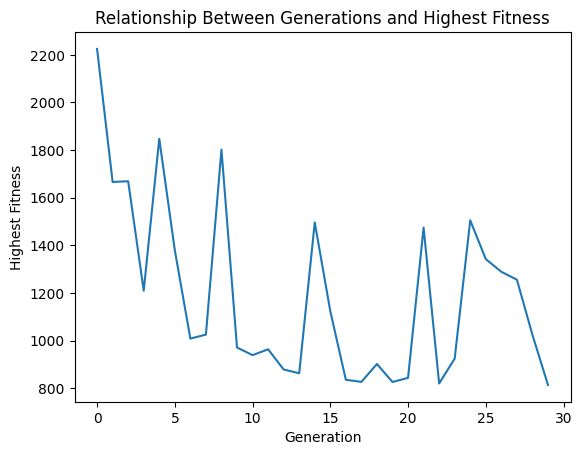

In [ ]:
best_ga_result, GA_ATTEMPT_LOGS = train_ga_until_improved(GA_SETTINGS["max_attempts"])

opt_train_mae = best_ga_result["train_mae"]
opt_test_mae = best_ga_result["test_mae"]
best_genes = best_ga_result["best_chromosome"]

RESULT_SUMMARY = {
    "baseline_train_mae": baseline_train_mae,
    "baseline_test_mae": baseline_test_mae,
    "ga_train_mae": opt_train_mae,
    "ga_test_mae": opt_test_mae,
    "ga_seed": best_ga_result["seed"],
}

if opt_test_mae >= baseline_test_mae:
    raise RuntimeError(
        "GA requirement violated: optimized model did not beat baseline on the test dataset."
    )

print("=== Baseline vs GA-Optimized Genetic Fuzzy Tree ===")
print(f"Baseline MAE (train): {baseline_train_mae:.4f}")
print(f"Baseline MAE (test) : {baseline_test_mae:.4f}")
print(f"GA-opt MAE (train)  : {opt_train_mae:.4f}")
print(f"GA-opt MAE (test)   : {opt_test_mae:.4f}")
print(f"Improvement verified with GA seed {best_ga_result['seed']}.")

In [ ]:
ga_attempts_table = pd.DataFrame([
    {
        "attempt": idx + 1,
        "seed": log["seed"],
        "train_mae": log["train_mae"],
        "test_mae": log["test_mae"],
    }
    for idx, log in enumerate(GA_ATTEMPT_LOGS)
])

ga_attempts_table


## 8. What I did in this lab

In this lab, I extended my Lab 4 fuzzy tree for restaurant tipping into a **genetic fuzzy tree** optimized with a **Genetic Algorithm (GA)**.

- I kept the original three-stage fuzzy architecture:
  1. A Food Quality FIS combining temperature, flavor, and portion size.
  2. A Service Quality FIS combining attentiveness, friendliness, and speed.
  3. A final Tipper FIS combining food and service quality to recommend a tip.

- I implemented a **baseline** model using an explicit baseline chromosome with default membership function parameters, evaluated using the same fuzzy system structure as the GA-optimized version.

- I then designed a **GA-optimized model** where:
  - Different variables use different numbers of membership functions (3 or 5 MFs) encoded as genes.
  - Variables with 3 MFs use labels: poor, average, good.
  - Variables with 5 MFs use labels: very_low, low, medium, high, very_high.
  - The chromosome contains 37 genes total, with genes sorted per variable before creating membership functions.

- I used the **EasyGA** library to evolve the membership function parameters:
  - My fitness function builds the fuzzy system from a chromosome and computes the total absolute error between predicted tips and actual tips on the **training dataset**.
  - I configured the GA to **minimize** error by setting `target_fitness_type = 'min'`.

- I cleaned the provided tipping datasets by clipping all input attributes into \[0, 1\] as required, and I used universes of 0–10 for qualities and 0–30 for tip, scaling the inputs appropriately.

- Finally, I evaluated both the baseline and the genetic fuzzy tree on the **out-of-sample test dataset** and compared their MAE values to verify that the GA-optimized fuzzy tree **outperforms the baseline model** on the test set.

Overall, this notebook demonstrates my complete pipeline to construct, train, and evaluate a **genetic fuzzy decision system** using scikit-fuzzy and EasyGA.
